# Notebook 08 — Risk: Stress Periods, Tail Diagnostics, Sensitivity Tests

This notebook answers: **when does the strategy struggle, how bad can the tails get, and how sensitive are results to key knobs?**


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from quant.evaluation.performance import (
    equity_curve,
    drawdown_series,
    performance_summary,
)

from quant.config.strategy import (
    SCALE_CAP,
    MAX_GROSS,
)

from quant.portfolios.weights import portfolio_vol_target_weights
from quant.utils.project_root import set_root

PROJECT_ROOT = set_root()
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\johng\code\quant-projects\quant-projects


## Load strategy objects

Expected files (created in earlier notebooks):
- `data/derived/portfolio_returns.parquet`
- `data/derived/weights_vol_target.parquet` (pre portfolio vol scaling)
- `data/processed/portfolio_vol_ann_tm1.parquet`
- `data/processed/prices_simple_returns.parquet` (asset simple returns)


In [3]:
r_port = pd.read_parquet("data/derived/portfolio_returns.parquet").iloc[:, 0]
r_port.name = "strategy"

# Pre-scaling weights (asset-vol-targeted) and portfolio vol estimate (t-1)
w_pre = pd.read_parquet("data/derived/weights_vol_target.parquet")
port_vol_tm1 = pd.read_parquet("data/processed/portfolio_vol_ann_tm1_pre.parquet")[
    "port_vol_ann_tm1"
]

# Asset returns (simple)
asset_rets = pd.read_parquet("data/processed/prices_simple_returns.parquet")

print(
    "strategy returns:", r_port.index.min(), "->", r_port.index.max(), "n=", len(r_port)
)
print("w_pre shape:", w_pre.shape)
print("asset_rets shape:", asset_rets.shape)

strategy returns: 2007-01-02 00:00:00 -> 2025-12-31 00:00:00 n= 5022
w_pre shape: (5022, 15)
asset_rets shape: (5022, 15)


In [4]:
# Optional benchmark: use SPX if present in your returns panel
bench_col_candidates = [
    c
    for c in asset_rets.columns
    if c.lower() in {"spx", "spx index", "spx_px", "sp500", "s&p 500"}
]
bench = None
if "spx" in asset_rets.columns:
    bench = asset_rets["spx"].copy()
elif len(bench_col_candidates) > 0:
    bench = asset_rets[bench_col_candidates[0]].copy()

if bench is not None:
    bench.name = "benchmark"
    print("Benchmark column:", bench.name)
else:
    print("No obvious benchmark column found (ok).")

Benchmark column: benchmark


## 1) Stress periods

We evaluate performance over well-known market regimes.


In [5]:
STRESS_PERIODS = {
    "GFC (2008-2009)": ("2008-09-01", "2009-06-30"),
    "Euro crisis (2011)": ("2011-07-01", "2011-12-31"),
    "COVID crash (2020)": ("2020-02-15", "2020-04-30"),
    "Inflation / rates shock (2022)": ("2022-01-01", "2022-10-31"),
}


def slice_period(s: pd.Series, start: str, end: str) -> pd.Series:
    return s.loc[pd.to_datetime(start) : pd.to_datetime(end)]


def period_table(name: str, r: pd.Series, periods_per_year: int = 252) -> pd.Series:
    out = performance_summary(r, periods_per_year=periods_per_year)
    out.name = name
    return out


rows_strat = []
rows_bench = []
for nm, (s, e) in STRESS_PERIODS.items():
    r = slice_period(r_port, s, e)
    rows_strat.append(period_table(nm, r))
    r = slice_period(bench, s, e)
    rows_bench.append(period_table(nm, r))

stress_bench = pd.DataFrame(rows_bench)
stress_strat = pd.DataFrame(rows_strat)

stress_multi = pd.concat(
    {
        "Strategy": stress_strat,
        "Benchmark": stress_bench,
    },
    axis=1,
)
# Put metric on top, then Strategy/BM underneath
stress_multi = stress_multi.swaplevel(0, 1, axis=1)

# --- THIS IS THE KEY LINE YOU WANT ---
stress_multi = stress_multi.sort_index(axis=1, level=0)
display(stress_multi)

CAGR              Calmar            \
                               Benchmark  Strategy Benchmark  Strategy   
GFC (2008-2009)                -0.316088  0.164226 -0.668790  1.408567   
Euro crisis (2011)             -0.088496 -0.011905 -0.471492 -0.151048   
COVID crash (2020)             -0.494595 -0.416475 -1.457908 -2.570729   
Inflation / rates shock (2022) -0.213518  0.321812 -0.839791  5.500832   

                                   MaxDD              Sharpe            \
                               Benchmark  Strategy Benchmark  Strategy   
GFC (2008-2009)                -0.472627 -0.116591 -0.561011  1.150381   
Euro crisis (2011)             -0.187693 -0.078813 -0.165846 -0.067253   
COVID crash (2020)             -0.339250 -0.162007 -0.719762 -2.278902   
Inflation / rates shock (2022) -0.254251 -0.058502 -0.888333  2.460952   

                                 Sortino                 Vol            
                               Benchmark  Strategy Benchmark  Strategy  
GFC (2008-2009)                -0.909160  2.179701  0.475831  0.140736  
Euro crisis (2011)             -0.261139 -0.108130  0.295730  0.101684  
COVID crash (2020)             -1.169407 -3.585331  0.653444  0.225231  
Inflation / rates shock (2022) -1.437147  4.765027  0.238334  0.116158

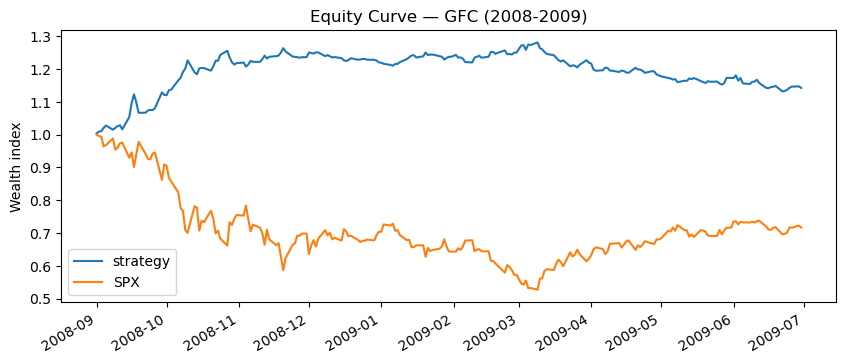

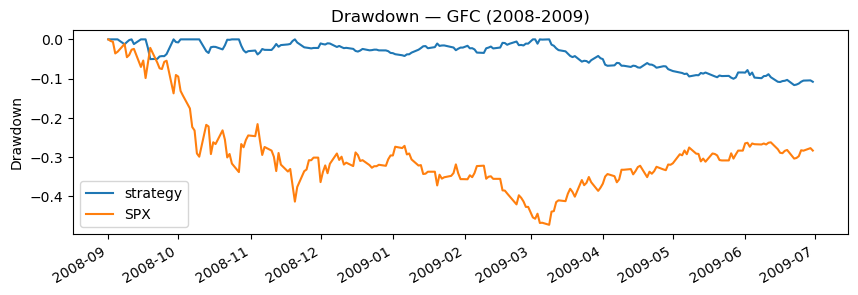

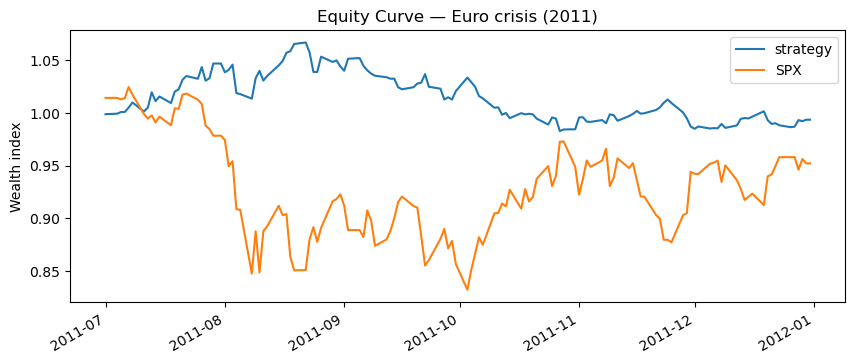

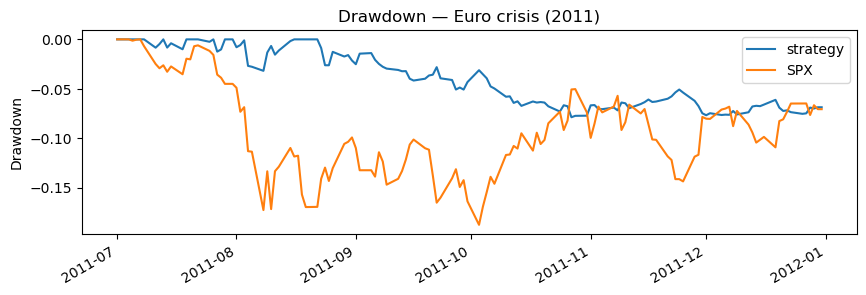

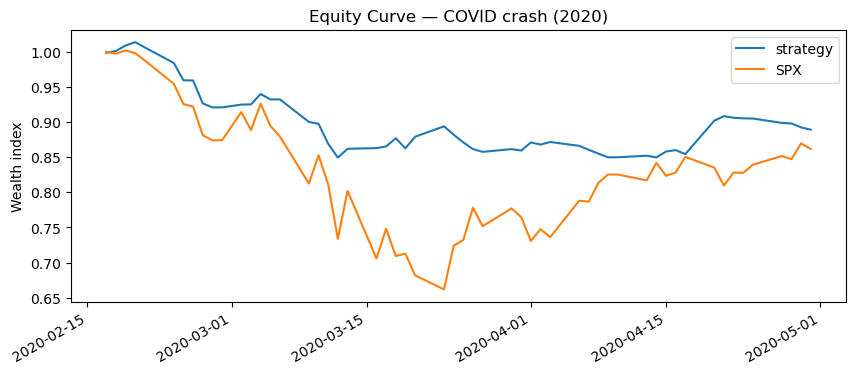

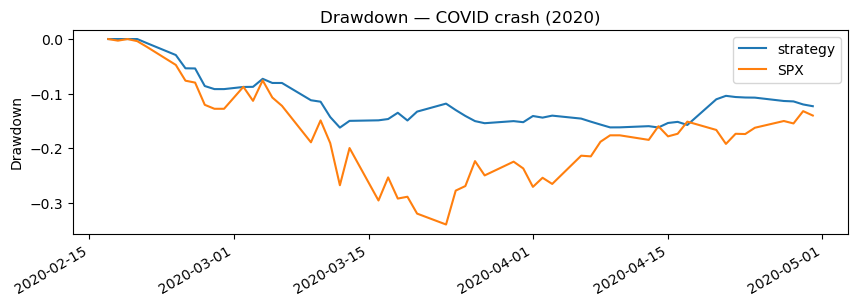

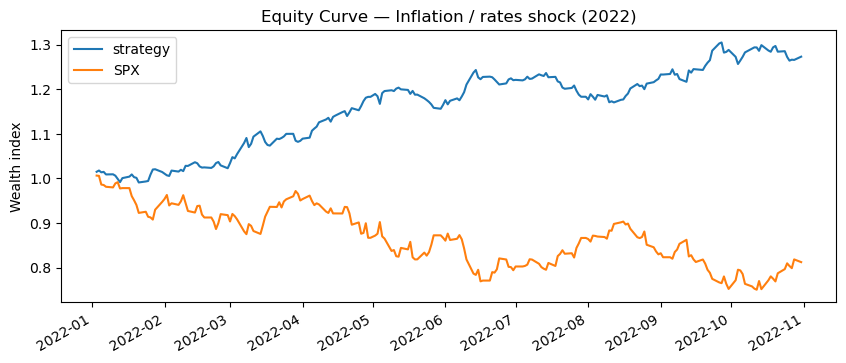

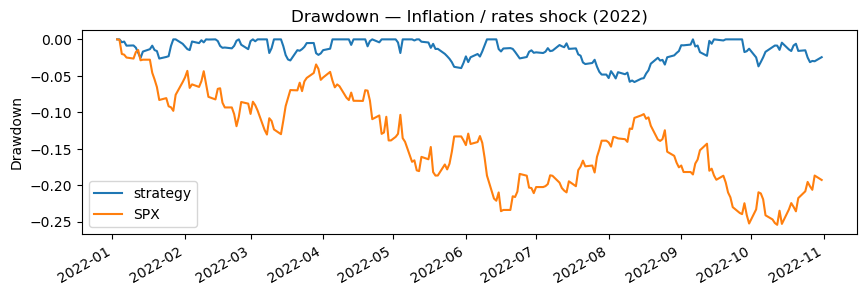

In [6]:
# Plot equity + drawdown for each stress period
for nm, (s, e) in STRESS_PERIODS.items():
    r_p = slice_period(r_port, s, e)
    r_b = slice_period(bench, s, e)
    if len(r_p.dropna()) == 0:
        continue

    ax = equity_curve(r_p).plot(figsize=(10, 4), title=f"Equity Curve — {nm}")

    if bench is not None:
        equity_curve(r_b).plot(ax=ax, label="SPX")
    ax.set_ylabel("Wealth index")
    ax.legend()
    plt.show()

    ax = drawdown_series(r_p).plot(figsize=(10, 3), title=f"Drawdown — {nm}")
    if bench is not None:
        drawdown_series(r_b).plot(ax=ax, label="SPX")
    ax.set_ylabel("Drawdown")
    ax.legend()
    plt.show()

## 2) Tail risk diagnostics

We compute simple tail statistics: VaR / CVaR, worst days, and downside moments.


In [7]:
def tail_stats_series(r: pd.Series) -> pd.Series:
    r = r.dropna()

    levels = [0.01, 0.05]

    var = {f"VaR_{int(a*100)}%": float(r.quantile(a)) for a in levels}

    cvar = {}
    for a in levels:
        q = r.quantile(a)
        cvar[f"CVaR_{int(a*100)}%"] = float(r[r <= q].mean())

    return pd.Series(
        {
            **var,
            **cvar,
            "Skew": float(r.skew()),
            "Kurtosis": float(r.kurtosis()),
        }
    )


tail_strat = tail_stats_series(r_port)
tail_bench = tail_stats_series(bench)
tail_compare = pd.DataFrame([tail_strat, tail_bench], index=["Strategy", "Benchmark"]).T
display(tail_compare)

,Strategy,Benchmark
VaR_1%,-0.017961,-0.035067
VaR_5%,-0.010946,-0.018302
CVaR_1%,-0.024317,-0.052265
CVaR_5%,-0.015595,-0.030265
Skew,-0.196530,-0.205963
Kurtosis,3.894718,13.070382


returns are far less fat-tailed than equities.

In [8]:
# Worst days
worst = r.sort_values().head(20).to_frame("return")
worst["cum_loss"] = (1 + worst["return"]).cumprod() - 1
display(worst)

,return,cum_loss
2022-09-13,-0.043237,-0.043237
2022-05-18,-0.040395,-0.081885
2022-06-13,-0.038768,-0.117479
2022-04-29,-0.036285,-0.149501
2022-05-05,-0.035650,-0.179821
2022-08-26,-0.033688,-0.207451
2022-06-16,-0.032512,-0.233219
2022-05-09,-0.032037,-0.257784
2022-03-07,-0.029518,-0.279693
2022-06-10,-0.029110,-0.300661


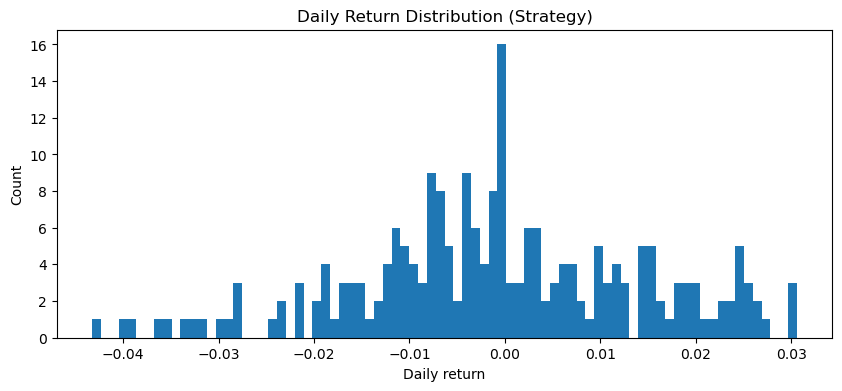

In [9]:
# Return distribution (quick visual)
plt.figure(figsize=(10, 4))
plt.hist(r.values, bins=80)
plt.title("Daily Return Distribution (Strategy)")
plt.xlabel("Daily return")
plt.ylabel("Count")
plt.show()

## 3) Sensitivity tests

We vary a few key knobs and recompute returns:
- Portfolio target volatility (e.g., 8%, 10%, 12%)
- Simple transaction cost per unit turnover (e.g., 0, 5, 10 bps)

This uses your **pre-scaling weights** (`weights_vol_target.parquet`) and the **t-1 portfolio vol estimate** (`portfolio_vol_ann_tm1.parquet`).


In [10]:
def compute_portfolio_returns(
    weights: pd.DataFrame, asset_returns: pd.DataFrame
) -> pd.Series:
    # Align on common dates/assets
    w, a = weights.align(asset_returns, join="inner", axis=0)
    w, a = w.align(a, join="inner", axis=1)
    return (w * a).sum(axis=1)


def turnover_series(weights: pd.DataFrame) -> pd.Series:
    return weights.diff().abs().sum(axis=1)


def run_variant(target_vol: float, cost_bps: float) -> pd.Series:
    w_scaled = portfolio_vol_target_weights(
        weights=w_pre,
        port_vol_tm1=port_vol_tm1,
        target_vol=target_vol,
        scale_cap=SCALE_CAP,
        max_gross=MAX_GROSS,
    )
    r_gross = compute_portfolio_returns(w_scaled, asset_rets)
    to = turnover_series(w_scaled)
    costs = (cost_bps / 10_000) * to
    r_net = (r_gross - costs).rename(f"vol={target_vol:.2f}, cost={cost_bps:.0f}bps")
    return r_net

In [12]:
vol_grid = [0.08, 0.10, 0.12]
cost_grid = [0.0, 5.0, 10.0]

variant_summaries = []
variant_eq = []

for tv in vol_grid:
    for cb in cost_grid:
        r_v = run_variant(tv, cb)
        s = performance_summary(r_v, periods_per_year=252)
        s.name = r_v.name
        variant_summaries.append(s)
        variant_eq.append(equity_curve(r_v).rename(r_v.name))

sens_table = pd.DataFrame(variant_summaries)
display(sens_table.sort_values("Sharpe", ascending=False))

,CAGR,Vol,Sharpe,Sortino,MaxDD,Calmar
"vol=0.08, cost=0bps",0.044519,0.087605,0.541063,0.868928,-0.180547,0.246581
"vol=0.10, cost=0bps",0.052092,0.106721,0.529265,0.849831,-0.220633,0.236103
"vol=0.12, cost=0bps",0.057606,0.122780,0.517636,0.831826,-0.245683,0.234473
"vol=0.08, cost=5bps",0.035833,0.087614,0.445688,0.713218,-0.193619,0.185070
"vol=0.10, cost=5bps",0.042077,0.106727,0.439609,0.703564,-0.234825,0.179184
"vol=0.12, cost=5bps",0.046949,0.122783,0.435130,0.697151,-0.259721,0.180767
"vol=0.12, cost=10bps",0.036399,0.122789,0.352620,0.563277,-0.273500,0.133085
"vol=0.08, cost=10bps",0.027218,0.087626,0.350323,0.558626,-0.206799,0.131618
"vol=0.10, cost=10bps",0.032157,0.106736,0.349955,0.558254,-0.248760,0.129267


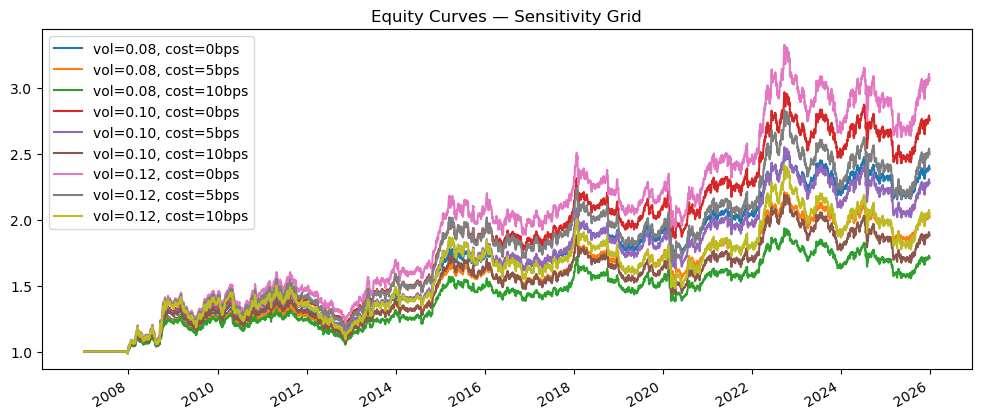

: 

In [ ]:
pd.concat(variant_eq, axis=1).plot(
    figsize=(12, 5), title="Equity Curves — Sensitivity Grid"
)
plt.show()